In [98]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OneHotEncoder

### internally LogisticRegression uses softmax if label is 3 and it is nothing but multinomial multiclass

In [99]:
''' 
1) penalty: Literal['l1','l2','l3','elasticnet'] | None= l2 (default)
   model=LogisticRegression(penalty='l1')
   model=LogisticRegression(penalty='l2')
   model=LogisticRegression(penalty='elasticnet')


2) solver --> Algorithm to use in the optimization problem. Default is 'lbfgs'. 
    {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'

To choose a solver,  you might want to consider the following aspects:

*   'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.
*   For multiclass problems (n_classes >= 3), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.
*   'newton-cholesky' is a good choice for n_samples >> n_features * n_classes, especially with one-hot encoded categorical features with rare categories. 
     Be aware that the memory usage of this solver has a quadratic dependency on n_features * n_classes because it explicitly computes the full Hessian matrix.
*   For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;
*   'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the OneVsRestClassifier.


The choice of the algorithm depends on the penalty chosen 
(l1_ratio=0 for L2-penalty, l1_ratio=1 for L1-penalty and 0 < l1_ratio < 1 for Elastic-Net) and on (multinomial) multiclass support:


solver	            l1_ratio	                multinomial multiclass
'lbfgs'	            l1_ratio=0	                yes
'liblinear'	        l1_ratio=1 or l1_ratio=0	no
'newton-cg'	        l1_ratio=0             	    yes
'newton-cholesky'	l1_ratio=0	                yes
'sag'	            l1_ratio=0	                yes
'saga'	            0<=l1_ratio<=1	            yes


3) max_iter
    max_iter: Int = 100,

*4) class_weight   (based on target column we can find out whether class_weight is 'balanced' or 'imbalanced') if count is almost equal that is balance like 450 & 500 if not then that dataset is imbalance.
    we can find the given dataset is balanced or imbalanced by knowing value count of target column    

    *** how to handle imbalance dataset? 
        we can handle it by two ways
        i)  class_weight
        ii) Re_sampling

    class_weight = None | 'balanced' 


5) C: Float = 1 --> It is a regularization strength
   It is used to decide whether the model is going to underfit or goodfit or overfit

   # if its strength is more strickk then it comes under 'underfit'
   # if its strength is too linear then it comes under 'overfit'
   # if its strength is too strick then it comes under 'goodfit'


 '''

" \n1) penalty: Literal['l1','l2','l3','elasticnet'] | None= l2 (default)\n   model=LogisticRegression(penalty='l1')\n   model=LogisticRegression(penalty='l2')\n   model=LogisticRegression(penalty='elasticnet')\n\n\n2) solver --> Algorithm to use in the optimization problem. Default is 'lbfgs'. \n    {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'\n\nTo choose a solver,  you might want to consider the following aspects:\n\n*   'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.\n*   For multiclass problems (n_classes >= 3), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.\n*   'newton-cholesky' is a good choice for n_samples >> n_features * n_classes, especially with one-hot encoded categorical features with rare categories. \n     Be aware that the memory usage of this solver has a quadratic dependency on n_features * n_classes because it explicitly com

In [100]:
df=pd.read_csv('loan_approval_dataset.csv')

In [101]:
df

,Age,Salary,Credit_Score,Loan_Amount,Loan_Term,Employment_Status,Residence_Type,Previous_Default,Loan_Approved
0,56,136748,584,38209,36 months,Employed,Owned,Yes,Yes
1,46,25287,815,27424,24 months,Self-Employed,Rented,No,Yes
2,32,146593,398,42396,12 months,Unemployed,Rented,Yes,Yes
3,60,54387,696,11370,24 months,Unemployed,Owned,No,No
4,25,28512,788,14528,12 months,Employed,Owned,No,No
...,...,...,...,...,...,...,...,...,...
995,22,49241,500,41020,24 months,Self-Employed,Owned,No,Yes
996,40,116214,423,12415,48 months,Self-Employed,Owned,No,Yes
997,27,64569,300,28155,36 months,Self-Employed,Rented,Yes,Yes
998,61,31745,490,48884,12 months,Self-Employed,Mortgage,No,Yes


In [102]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Age                1000 non-null   int64
 1   Salary             1000 non-null   int64
 2   Credit_Score       1000 non-null   int64
 3   Loan_Amount        1000 non-null   int64
 4   Loan_Term          1000 non-null   str  
 5   Employment_Status  1000 non-null   str  
 6   Residence_Type     1000 non-null   str  
 7   Previous_Default   1000 non-null   str  
 8   Loan_Approved      1000 non-null   str  
dtypes: int64(4), str(5)
memory usage: 70.4 KB


In [103]:
x=df.drop(columns='Loan_Approved')
y=df.Loan_Approved

In [104]:
xtrain, xtest, ytrain, ytest=train_test_split(x,y,train_size=0.8, random_state=42)

In [105]:
x.corr(numeric_only=True)   # It is used to check multi-colinearity problem

,Age,Salary,Credit_Score,Loan_Amount
Age,1.000000,0.060125,-0.018835,-0.000500
Salary,0.060125,1.000000,-0.011185,-0.000635
Credit_Score,-0.018835,-0.011185,1.000000,0.008741
Loan_Amount,-0.000500,-0.000635,0.008741,1.000000


In [106]:
nums_col=x.select_dtypes(include='number').columns
obj_cols=x.select_dtypes(include='object').columns

C:\Users\idris\AppData\Local\Temp\ipykernel_12076\749974036.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  obj_cols=x.select_dtypes(include='object').columns


In [107]:
df

,Age,Salary,Credit_Score,Loan_Amount,Loan_Term,Employment_Status,Residence_Type,Previous_Default,Loan_Approved
0,56,136748,584,38209,36 months,Employed,Owned,Yes,Yes
1,46,25287,815,27424,24 months,Self-Employed,Rented,No,Yes
2,32,146593,398,42396,12 months,Unemployed,Rented,Yes,Yes
3,60,54387,696,11370,24 months,Unemployed,Owned,No,No
4,25,28512,788,14528,12 months,Employed,Owned,No,No
...,...,...,...,...,...,...,...,...,...
995,22,49241,500,41020,24 months,Self-Employed,Owned,No,Yes
996,40,116214,423,12415,48 months,Self-Employed,Owned,No,Yes
997,27,64569,300,28155,36 months,Self-Employed,Rented,Yes,Yes
998,61,31745,490,48884,12 months,Self-Employed,Mortgage,No,Yes


<Axes: >

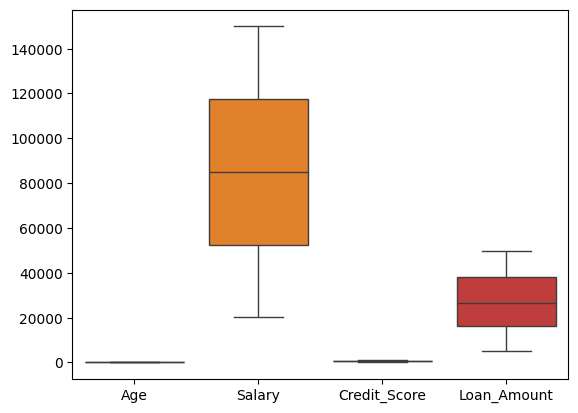

In [108]:
sns.boxplot(x[nums_col])


- Scaling --> MinMaxScaler
- Encoding --> OneHotEncoder

Why scaling ?
Feature cols values are in different range(scale), so we can use scaling to equal importance for all the features cols


Why encoding ?
Algorithms can understand only numbers not string.


Which Scaling?
Here we don't have any outliers, so we can use MinMax Scaler.

Which Encoding?
The feature columns have two or more columns, so we are using the OneHotEncoder.

### To check unique values

x[obj_cols].nunique()

In [109]:
x[obj_cols].nunique()

Loan_Term            4
Employment_Status    3
Residence_Type       3
Previous_Default     2
dtype: int64

In [ ]:
encoder=OneHotEncoder(sparse_output=False, handle_unknown='ignore') # it assign the zero to unknown values , by this it handle unknown values
scaling=MinMaxScaler()
model=LogisticRegression(penalty=None)

In [111]:
# model.fit(xtrain,ytrain) ---> ValueError

In [112]:
# xtrain
xtrain[nums_col]=scaling.fit_transform(xtrain[nums_col])
# xtrain[obj_cols]=encoder.fit_transform(xtrain[obj_cols])

encoded_values=encoder.fit_transform(xtrain[obj_cols])
encoded_cols=encoder.get_feature_names_out()

xtrain[encoded_cols]=encoded_values
xtrain.drop(columns=obj_cols, inplace=True)



In [113]:
xtrain

,Age,Salary,Credit_Score,Loan_Amount,Loan_Term_12 months,Loan_Term_24 months,Loan_Term_36 months,Loan_Term_48 months,Employment_Status_Employed,Employment_Status_Self-Employed,Employment_Status_Unemployed,Residence_Type_Mortgage,Residence_Type_Owned,Residence_Type_Rented,Previous_Default_No,Previous_Default_Yes
29,0.565217,0.503206,0.377737,0.267437,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
535,0.434783,0.517503,0.344891,0.125955,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
695,0.586957,0.227507,0.843066,0.766342,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
557,0.630435,0.425421,0.928832,0.792145,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
836,0.608696,0.623919,0.372263,0.599124,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,0.739130,0.759429,0.709854,0.592266,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
270,0.173913,0.889773,0.160584,0.388186,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
860,1.000000,0.884776,0.698905,0.078281,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
435,0.173913,0.213857,0.987226,0.906103,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0


In [114]:
#xtest
xtest[nums_col]=scaling.transform(xtest[nums_col])
# xtrain[obj_cols]=encoder.fit_transform(xtrain[obj_cols])

encoded_values=encoder.transform(xtest[obj_cols])
# encoded_cols=encoder.get_feature_names_out()

xtest[encoded_cols]=encoded_values
xtest.drop(columns=obj_cols, inplace=True)

In [115]:
model.fit(xtrain, ytrain)

c:\Users\idris\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",None
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass`

## Model Evaluation

In [116]:
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,recall_score,f1_score
import matplotlib.pyplot as plt
import numpy as np

In [117]:
ytrain_pred=model.predict(xtrain)
matrix=confusion_matrix(ytrain,ytrain_pred)

In [118]:
ytrain.value_counts()

Loan_Approved
Yes    403
No     397
Name: count, dtype: int64

In [119]:
precision_score(ytrain, ytrain_pred, pos_label='Yes')

0.5471698113207547

In [120]:
pred_yes=np.sum(matrix[:,1])
pred_no=np.sum(matrix[:,0])

In [121]:
pred_yes

np.int64(424)

In [122]:
pred_no

np.int64(376)

### CONCLUSION:

#### Out of all the predicted 'YES' labels (425), 54% labels are correctly predicted as 'YES'.

#### Out of all the predicted 'YES' labels (425), 46% labels are wrongly predicted as 'YES'.

In [123]:
precision_score(ytrain, ytrain_pred, pos_label='Yes')

0.5471698113207547

### CONCLUSION:

#### Out of all the predicted 'NO' labels (375), 54% labels are correctly predicted as 'NO'.

#### Out of all the predicted 'NO' labels (375), 46% labels are wrongly predicted as 'NO'.

In [124]:
recall_score(ytrain, ytrain_pred, pos_label='Yes')

0.575682382133995

### CONCLUSION:

#### Out of all the actual 'Yes' labels (403), 57% labels are correctly predicted as 'Yes'.

#### Out of all the actual 'Yes' labels (403), 43% labels are wrongly predicted as 'No'.

In [125]:
recall_score(ytrain, ytrain_pred, pos_label='No')

0.5163727959697733

### CONCLUSION:

#### Out of all the actual 'No' labels (397), 51% labels are correctly predicted as 'No'.

#### Out of all the actual 'No' labels (397), 49% labels are wrongly predicted as 'No'.

In [126]:
accuracy_score(ytrain, ytrain_pred)

0.54625

### CONCLUSION:

#### Out of all the samples (800) 54.75% samples are correctly predicted.

### Final Conclusion:

#### Model performance on train data is bad, so model is not learned data patterns properly.

#### The model i